In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from google.colab import drive
drive.mount('/content/drive')

BASE = Path("/content/drive/MyDrive/CS685/linkedin")
PLOT_DIR = BASE / "plots"
PLOT_DIR.mkdir(exist_ok=True)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f"✓ Saving plots to: {PLOT_DIR}")

Mounted at /content/drive
✓ Saving plots to: /content/drive/MyDrive/CS685/linkedin/plots


Load All Data

In [ ]:
# Load annotated data
annot = pd.read_csv(BASE / "sentences_annotated_clean.csv")
print(f"Annotated data: {len(annot)} sentences")

# Load results
e2e_results = pd.read_csv(BASE / "end_to_end_results.csv")
print(f"E2E results loaded")

# Parse spans
def parse_spans(raw):
    if pd.isna(raw):
        return []
    return [s.strip() for s in str(raw).split(';') if s.strip()]

annot['spans_list'] = annot['spans'].apply(parse_spans)
annot['num_skills'] = annot['spans_list'].apply(len)
annot['sent_len'] = annot['sentence'].apply(lambda x: len(str(x).split()))

Annotated data: 700 sentences
E2E results loaded


PLOT 1: Domain Distribution

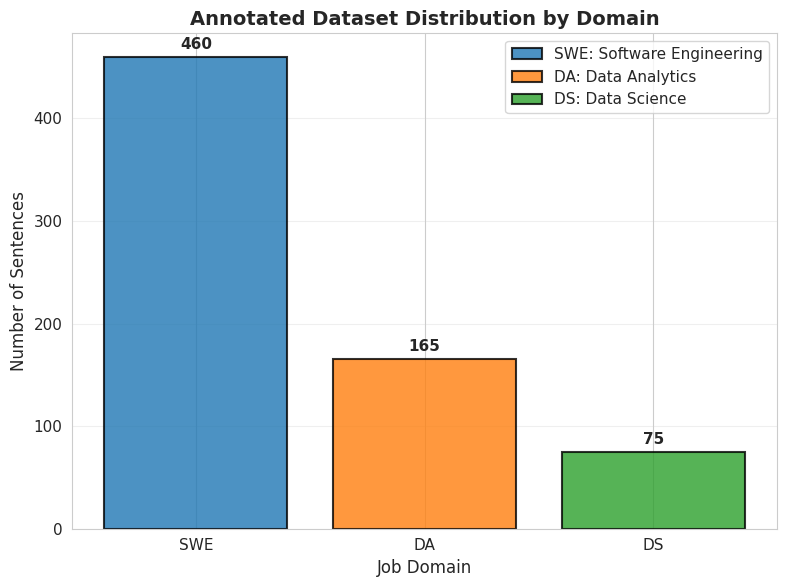

✓ Saved: 01_domain_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

domain_counts = annot['domain'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax.bar(domain_counts.index, domain_counts.values, color=colors,
              alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Job Domain', fontsize=12)
ax.set_ylabel('Number of Sentences', fontsize=12)
ax.set_title('Annotated Dataset Distribution by Domain', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add counts on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add legend with domain names
domain_map = {'SWE': 'Software Engineering', 'DS': 'Data Science', 'DA': 'Data Analytics'}
legend_labels = [f"{k}: {domain_map.get(k, k)}" for k in domain_counts.index]
ax.legend(bars, legend_labels, loc='upper right')

plt.tight_layout()
plt.savefig(PLOT_DIR / "01_domain_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_domain_distribution.png")

PLOT 2: Sentence Length Distribution

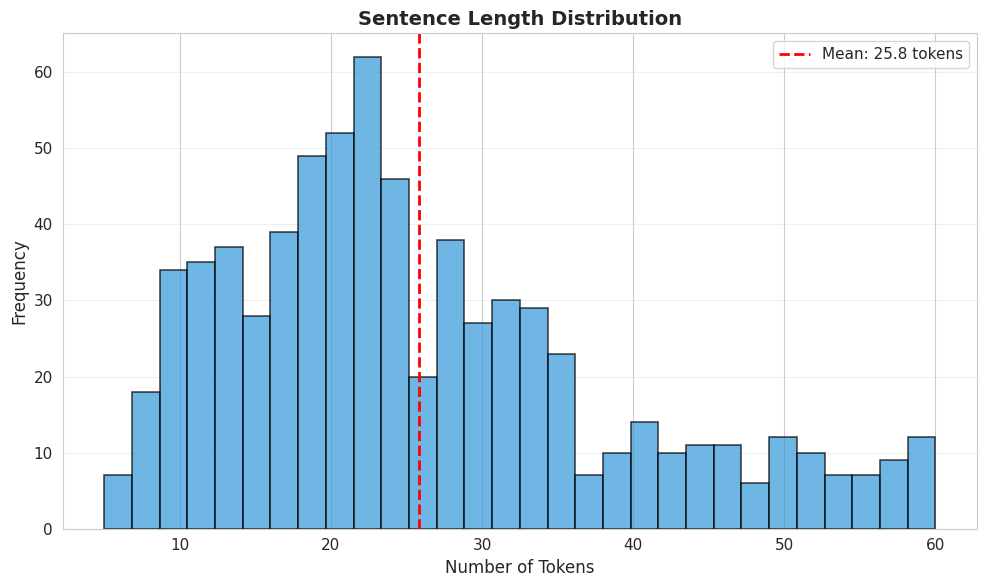

✓ Saved: 02_sentence_lengths.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(annot['sent_len'], bins=30, color='#3498db', alpha=0.7,
        edgecolor='black', linewidth=1.2)

# Add mean line
mean_len = annot['sent_len'].mean()
ax.axvline(mean_len, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mean_len:.1f} tokens')

ax.set_xlabel('Number of Tokens', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Sentence Length Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_sentence_lengths.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_sentence_lengths.png")

PLOT 3: Skills per Sentence

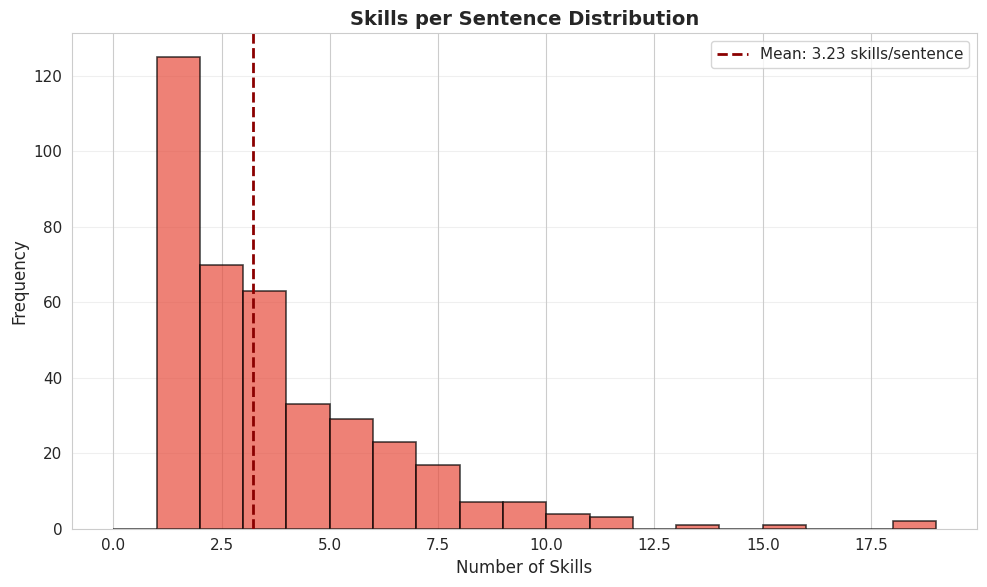

✓ Saved: 03_skills_per_sentence.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Filter to sentences with skills
with_skills = annot[annot['num_skills'] > 0]

ax.hist(with_skills['num_skills'], bins=range(0, max(with_skills['num_skills'])+2),
        color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.2)

# Add mean line
mean_skills = with_skills['num_skills'].mean()
ax.axvline(mean_skills, color='darkred', linestyle='--', linewidth=2,
           label=f'Mean: {mean_skills:.2f} skills/sentence')

ax.set_xlabel('Number of Skills', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Skills per Sentence Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_skills_per_sentence.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_skills_per_sentence.png")

PLOT 4: Baseline vs DistilBERT Comparison

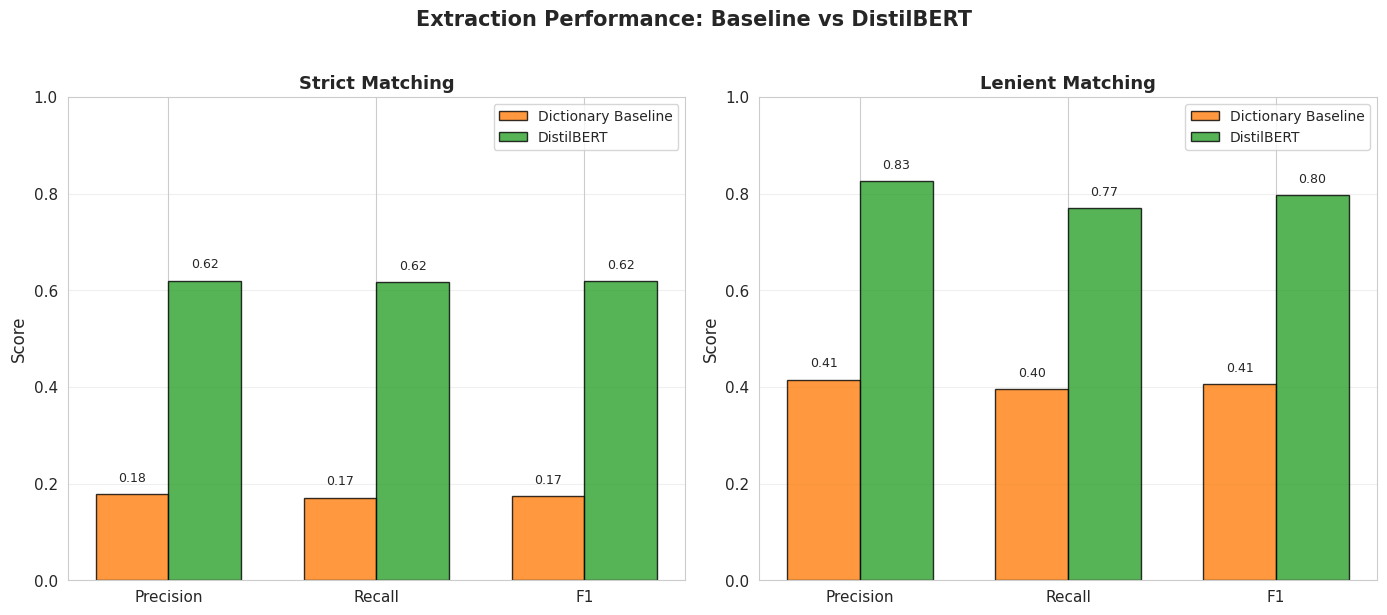

✓ Saved: 04_extraction_comparison.png


In [ ]:
baseline_results = {
    'strict': {
        'precision': 0.179,  # From notebook 02 - RAW baseline
        'recall': 0.171,
        'f1': 0.175
    },
    'lenient': {
        'precision': 0.415,
        'recall': 0.395,
        'f1': 0.405
    }
}

distilbert_results = {
    'strict': {
        'precision': 0.620,  # From notebook 04 - Final test at epoch 8
        'recall': 0.617,
        'f1': 0.619
    },
    'lenient': {
        'precision': 0.826,
        'recall': 0.770,
        'f1': 0.797
    }
}


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Strict matching
metrics = ['Precision', 'Recall', 'F1']
baseline_strict = [baseline_results['strict']['precision'],
                   baseline_results['strict']['recall'],
                   baseline_results['strict']['f1']]
distilbert_strict = [distilbert_results['strict']['precision'],
                     distilbert_results['strict']['recall'],
                     distilbert_results['strict']['f1']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_strict, width, label='Dictionary Baseline',
                color='#ff7f0e', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, distilbert_strict, width, label='DistilBERT',
                color='#2ca02c', alpha=0.8, edgecolor='black')

ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Strict Matching', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Lenient matching
baseline_lenient = [baseline_results['lenient']['precision'],
                    baseline_results['lenient']['recall'],
                    baseline_results['lenient']['f1']]
distilbert_lenient = [distilbert_results['lenient']['precision'],
                      distilbert_results['lenient']['recall'],
                      distilbert_results['lenient']['f1']]

bars3 = ax2.bar(x - width/2, baseline_lenient, width, label='Dictionary Baseline',
                color='#ff7f0e', alpha=0.8, edgecolor='black')
bars4 = ax2.bar(x + width/2, distilbert_lenient, width, label='DistilBERT',
                color='#2ca02c', alpha=0.8, edgecolor='black')

ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Lenient Matching', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Extraction Performance: Baseline vs DistilBERT',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_extraction_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 04_extraction_comparison.png")

PLOT 5: Complete Results Summary Table (as image)

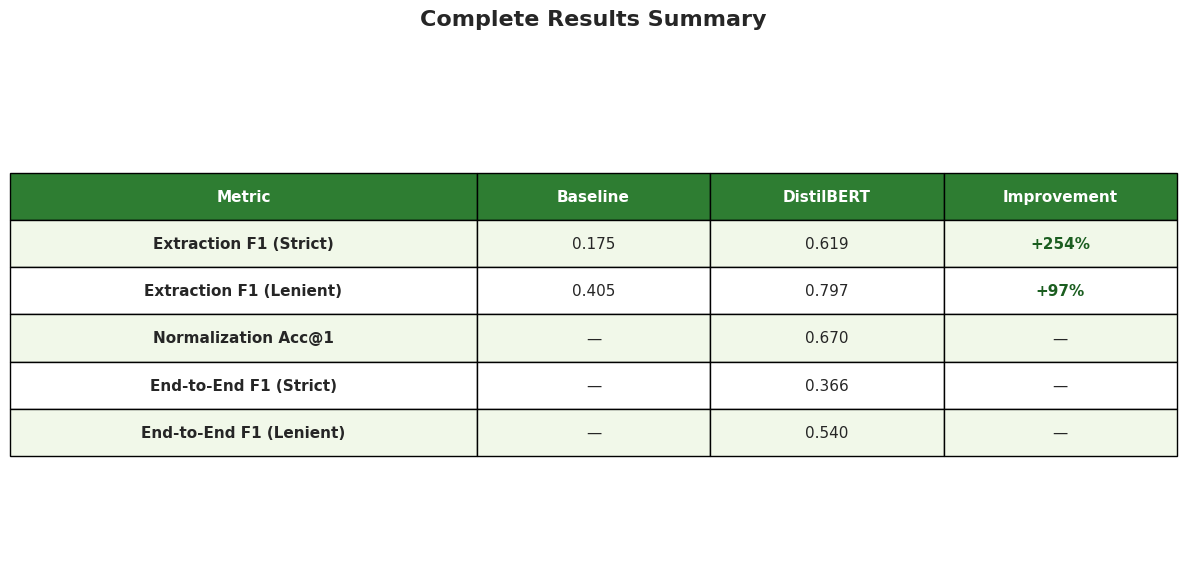

✓ Saved: 05_results_summary_table.png


In [ ]:
results_data = {
    'Metric': [
        'Extraction F1 (Strict)',
        'Extraction F1 (Lenient)',
        'Normalization Acc@1',
        'End-to-End F1 (Strict)',
        'End-to-End F1 (Lenient)'
    ],
    'Baseline': [
        f"{baseline_results['strict']['f1']:.3f}",
        f"{baseline_results['lenient']['f1']:.3f}",
        '—',
        '—',
        '—'
    ],
    'DistilBERT': [
        f"{distilbert_results['strict']['f1']:.3f}",
        f"{distilbert_results['lenient']['f1']:.3f}",
        '0.670',  # Approximate - update with your actual normalization accuracy if you have it
        f"{e2e_results.loc[e2e_results['matching']=='Strict', 'f1'].values[0]:.3f}",
        f"{e2e_results.loc[e2e_results['matching']=='Lenient', 'f1'].values[0]:.3f}"
    ],
    'Improvement': [
        f"+{((distilbert_results['strict']['f1'] / baseline_results['strict']['f1']) - 1) * 100:.0f}%",
        f"+{((distilbert_results['lenient']['f1'] / baseline_results['lenient']['f1']) - 1) * 100:.0f}%",
        '—',
        '—',
        '—'
    ]
}

results_df = pd.DataFrame(results_data)

# Create table plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=results_df.values, colLabels=results_df.columns,
                cellLoc='center', loc='center',
                colWidths=[0.40, 0.20, 0.20, 0.20])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
header_color = '#2E7D32'  # Dark green
for i in range(len(results_df.columns)):
    table[(0, i)].set_facecolor(header_color)
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style rows - alternate colors for readability
row_colors = ['#F1F8E9', '#FFFFFF']  # Light green and white
for i in range(len(results_df)):
    for j in range(len(results_df.columns)):
        # Alternate row colors
        table[(i+1, j)].set_facecolor(row_colors[i % 2])

        # Bold the metric names
        if j == 0:
            table[(i+1, j)].set_text_props(weight='bold')

        # Highlight improvement column
        if j == 3 and results_df.iloc[i, j] != '—':
            table[(i+1, j)].set_text_props(weight='bold', color='#1B5E20')

plt.title('Complete Results Summary', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_results_summary_table.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 05_results_summary_table.png")

PLOT 6: End-to-End Performance with CI

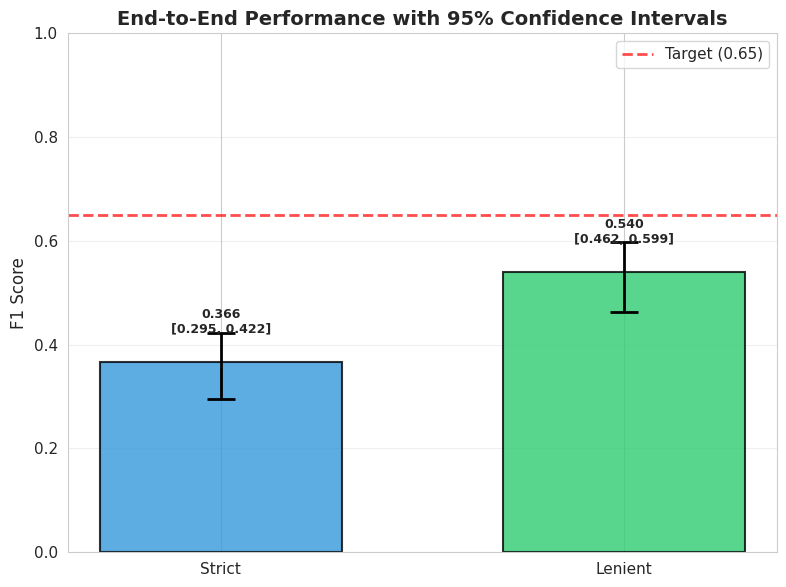

✓ Saved: 06_e2e_confidence_intervals.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Get data from e2e_results
matching_types = e2e_results['matching'].values
f1_scores = e2e_results['f1'].values
ci_low = e2e_results['f1_ci_low'].values
ci_high = e2e_results['f1_ci_high'].values

yerr_low = f1_scores - ci_low
yerr_high = ci_high - f1_scores

x_pos = np.arange(len(matching_types))
colors_bars = ['#3498db', '#2ecc71']

bars = ax.bar(x_pos, f1_scores, color=colors_bars, alpha=0.8,
              edgecolor='black', linewidth=1.5, width=0.6)
ax.errorbar(x_pos, f1_scores, yerr=[yerr_low, yerr_high],
            fmt='none', ecolor='black', capsize=10, capthick=2, linewidth=2)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('End-to-End Performance with 95% Confidence Intervals',
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(matching_types, fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add target line
ax.axhline(y=0.65, color='red', linestyle='--', linewidth=2,
           alpha=0.7, label='Target (0.65)')
ax.legend(fontsize=11)

# Add value labels
for i, (bar, f1, low, high) in enumerate(zip(bars, f1_scores, ci_low, ci_high)):
    ax.text(bar.get_x() + bar.get_width()/2., f1 + 0.05,
            f'{f1:.3f}\n[{low:.3f}, {high:.3f}]',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / "06_e2e_confidence_intervals.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_e2e_confidence_intervals.png")